# Mean-Reversion Diagnostics

This notebook investigates whether the spreads used in the pairs-trading strategy show statistical evidence of mean reversion behaviour. Earlier notebooks built the strategy, tested parameter sensitivity, and evaluated out of sample performance. Here, I add diagnostic tests that are directly connected to the stategy's core assumption: that large spread deviations tend to revert toward it's long-term mean.

The diagnostics include:
- Augmented Dickey-Fuller tests on the spread
- Engle-Granger cointegration tests on price pairs
- Ornstein-Uhlenbeck parameter estimates
- Hurst exponent estimates

These tests are not used to optimize the test period, they are used to understand whether the selected pairs have statistically meaningful mean-reversion properties.

In [2]:
# imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/nordi/Desktop/pairs-trading-backtest')

In [3]:
from src.data import download_prices
from src.pairs_trading import (
    compute_simple_returns,
    rank_pairs_by_correlation,
    compute_rolling_spread,
    run_dynamic_beta_backtest,
)

In [4]:
from statsmodels.tsa.stattools import adfuller, coint
import statsmodels.api as sm

## Data

The same ETF universe and sample period from earlier notebooks are used here. Goal is to test mean-reversion diagnostics on the same candidate pairs used in the strategy backtest.

In [9]:
tickers = [
    "SPY", "QQQ", "IWM",
    "XLK", "XLF", "XLE", "XLV",
    "XLY", "XLP", "XLI", "XLU",
    "TLT", "HYG", "LQD", "GLD",
]

start = "2015-01-01"
end = "2026-01-01"

prices = download_prices(
    tickers=tickers,
    start=start,
    end=end,
)

returns = compute_simple_returns(prices)

print("prices:", prices.shape)
print("returns:", returns.shape)

Loading SPY from cache...
Loading QQQ from cache...
Loading IWM from cache...
Loading XLK from cache...
Loading XLF from cache...
Loading XLE from cache...
Loading XLV from cache...
Loading XLY from cache...
Loading XLP from cache...
Loading XLI from cache...
Loading XLU from cache...
Loading TLT from cache...
Loading HYG from cache...
Loading LQD from cache...
Loading GLD from cache...
prices: (2766, 15)
returns: (2765, 15)


In [11]:
# train set
train_start = "2015-01-01"
train_end = "2019-12-31"
train_prices = prices.loc[train_start:train_end]

# test set
test_start = "2020-01-01"
test_end = "2026-01-01"
test_prices = prices.loc[test_start:test_end]

# compute returns
train_returns = compute_simple_returns(train_prices)

In [15]:
selected_pairs = [
    ("XLK", "QQQ"),
    ("SPY", "XLK"),
    ("SPY", "XLI"),
    ("XLK", "SPY"),
    ("XLI", "SPY"),
]

selected_pairs

[('XLK', 'QQQ'),
 ('SPY', 'XLK'),
 ('SPY', 'XLI'),
 ('XLK', 'SPY'),
 ('XLI', 'SPY')]

## Selected Pairs

The diagnostics are first applied to the directed pairs selected in the out of sample validation notebook. These were selected using training set information only. 

In [31]:
def adf_test_spread(spread: pd.Series) -> dict:
    """
    Run Augmented Dickey-Fuller test on a spread series.

    Null hypothesis:
        The spread has a unit root / is nonstationary.

    Small p-value:
        Evidence against the null, suggesting stationarity / mean reversion.
    """
    spread = spread.dropna()

    result = adfuller(spread)

    return {
        "adf_stat": result[0],
        "adf_p_value": result[1],
        "adf_lags": result[2],
        "adf_n_obs": result[3],
        "adf_critical_1pct": result[4]["1%"],
        "adf_critical_5pct": result[4]["5%"],
        "adf_critical_10pct": result[4]["10%"],
    }

In [33]:
def cointegration_test(
    prices: pd.DataFrame,
    ticker_y: str,
    ticker_x: str,
) -> dict:
    """
    Run Engle-Granger cointegration test on two price series.

    Null hypothesis:
        The two price series are not cointegrated.

    Small p-value:
        Evidence that a stationary linear combination may exist.
    """
    y = prices[ticker_y].dropna()
    x = prices[ticker_x].dropna()

    y, x = y.align(x, join="inner")

    stat, p_value, critical_values = coint(y, x)

    return {
        "coint_stat": stat,
        "coint_p_value": p_value,
        "coint_critical_1pct": critical_values[0],
        "coint_critical_5pct": critical_values[1],
        "coint_critical_10pct": critical_values[2],
    }

In [35]:
def estimate_ou_parameters(spread: pd.Series) -> dict:
    """
    Estimate OU-style mean-reversion parameters using the discrete AR(1) model:

        S_{t+1} = a + b S_t + eps_t

    For daily data:
        kappa = -log(b)
        half_life = log(2) / kappa
    """
    spread = spread.dropna()

    s_t = spread.shift(1).dropna()
    s_next = spread.loc[s_t.index]

    X = sm.add_constant(s_t)
    model = sm.OLS(s_next, X).fit()

    a = model.params.iloc[0]
    b = model.params.iloc[1]

    residuals = model.resid
    sigma_resid = residuals.std()

    if 0 < b < 1:
        kappa = -np.log(b)
        theta = a / (1 - b)
        half_life = np.log(2) / kappa
    else:
        kappa = np.nan
        theta = np.nan
        half_life = np.nan

    return {
        "ar1_intercept": a,
        "ar1_slope": b,
        "ou_kappa": kappa,
        "ou_theta": theta,
        "ou_half_life": half_life,
        "ou_sigma_resid": sigma_resid,
        "ou_r_squared": model.rsquared,
    }

In [37]:
def estimate_hurst_exponent(
    series: pd.Series,
    min_lag: int = 2,
    max_lag: int = 100,
) -> float:
    """
    Estimate the Hurst exponent using a log-log regression of lagged differences.

    Rule of thumb:
        H < 0.5  suggests mean reversion
        H ≈ 0.5  suggests random-walk-like behavior
        H > 0.5  suggests trending behavior
    """
    values = series.dropna().values

    lags = range(min_lag, max_lag)

    tau = [
        np.sqrt(np.std(values[lag:] - values[:-lag]))
        for lag in lags
    ]

    tau = np.array(tau)
    lags = np.array(list(lags))

    valid = tau > 0

    if valid.sum() < 2:
        return np.nan

    poly = np.polyfit(np.log(lags[valid]), np.log(tau[valid]), 1)

    hurst = 2.0 * poly[0]

    return hurst

## Training Set Mean-Reversion Diagnostics

The diagnostics are first computed on the training set only. This avoids using test-period information when assessing whether a pair appears suitable for a mean-reversion strategy.

In [40]:
hedge_window = 252

diagnostic_results = []

for ticker_y, ticker_x in selected_pairs:
    print(f"Running diagnostics for Y={ticker_y}/X={ticker_x}")

    rolling_spread_df = compute_rolling_spread(
        prices=train_prices,
        ticker_y=ticker_y,
        ticker_x=ticker_x,
        window=hedge_window,
    )

    spread = rolling_spread_df["spread"]

    adf_results = adf_test_spread(spread)
    coint_results = cointegration_test(
        prices=train_prices,
        ticker_y=ticker_y,
        ticker_x=ticker_x,
    )
    ou_results = estimate_ou_parameters(spread)
    hurst = estimate_hurst_exponent(spread)

    row = {
        "pair": f"Y={ticker_y}/X={ticker_x}",
        "ticker_y": ticker_y,
        "ticker_x": ticker_x,
        "spread_obs": len(spread.dropna()),
        "hurst": hurst,
    }

    row.update(adf_results)
    row.update(coint_results)
    row.update(ou_results)

    diagnostic_results.append(row)

diagnostics_df = pd.DataFrame(diagnostic_results)

diagnostics_df.round(4)

Running diagnostics for Y=XLK, X=QQQ
Running diagnostics for Y=SPY, X=XLK
Running diagnostics for Y=SPY, X=XLI
Running diagnostics for Y=XLK, X=SPY
Running diagnostics for Y=XLI, X=SPY


,pair,ticker_y,ticker_x,spread_obs,hurst,adf_stat,adf_p_value,adf_lags,adf_n_obs,adf_critical_1pct,...,coint_critical_1pct,coint_critical_5pct,coint_critical_10pct,ar1_intercept,ar1_slope,ou_kappa,ou_theta,ou_half_life,ou_sigma_resid,ou_r_squared
0,Y=XLK/X=QQQ,XLK,QQQ,1006,0.3734,-3.3546,0.0126,0,1005,-3.4369,...,-3.9052,-3.341,-3.0478,0.0039,0.9773,0.0230,0.1731,30.1806,0.0791,0.9541
1,Y=SPY/X=XLK,SPY,XLK,1006,0.3207,-4.8793,0.0000,7,998,-3.4369,...,-3.9052,-3.341,-3.0478,-0.0216,0.9671,0.0335,-0.6578,20.7180,0.7079,0.9361
2,Y=SPY/X=XLI,SPY,XLI,1006,0.2821,-3.4916,0.0082,0,1005,-3.4369,...,-3.9052,-3.341,-3.0478,0.0662,0.9747,0.0256,2.6184,27.0733,0.9225,0.9476
3,Y=XLK/X=SPY,XLK,SPY,1006,0.2982,-4.7108,0.0001,1,1004,-3.4369,...,-3.9052,-3.341,-3.0478,0.0092,0.9606,0.0402,0.2341,17.2242,0.1292,0.9225
4,Y=XLI/X=SPY,XLI,SPY,1006,0.2953,-3.7790,0.0031,2,1003,-3.4369,...,-3.9052,-3.341,-3.0478,-0.0127,0.9764,0.0239,-0.5380,29.0540,0.2779,0.9528


In [42]:
diagnostic_cols = [
    "pair",
    "adf_p_value",
    "coint_p_value",
    "hurst",
    "ar1_slope",
    "ou_kappa",
    "ou_half_life",
    "ou_r_squared",
    "spread_obs",
]

diagnostics_df[diagnostic_cols].sort_values("adf_p_value").round(4)

,pair,adf_p_value,coint_p_value,hurst,ar1_slope,ou_kappa,ou_half_life,ou_r_squared,spread_obs
1,Y=SPY/X=XLK,0.0000,0.0180,0.3207,0.9671,0.0335,20.7180,0.9361,1006
3,Y=XLK/X=SPY,0.0001,0.0221,0.2982,0.9606,0.0402,17.2242,0.9225,1006
4,Y=XLI/X=SPY,0.0031,0.5244,0.2953,0.9764,0.0239,29.0540,0.9528,1006
2,Y=SPY/X=XLI,0.0082,0.6367,0.2821,0.9747,0.0256,27.0733,0.9476,1006
0,Y=XLK/X=QQQ,0.0126,0.3902,0.3734,0.9773,0.0230,30.1806,0.9541,1006


## Interpreting the Diagnostics

The ADF test checks whether the spread appears stationary. The null hypothesis is that the spread has a unit root and is nonstationary. A small p-value provides evidence against this null, suggesting that the spread may be stationary.

The cointegration test checks whether the two price series have a stationary linear combination. A small p-value suggests that the pair may be cointegrated.

The OU estimate models the spread as a discrete mean-reverting process. The half-life estimates how many trading days it takes for a spread deviation to decay halfway back toward its mean.

The Hurst exponent provides another rough diagnostic. Values below 0.5 suggest mean-reverting behaviour, values near 0.5 suggest random-walk like behaviour, and values above 0.5 suggest trending behaviour.

In [46]:
# uses out of sample results from notebook 04
oos_results = pd.DataFrame(
    [
        {"pair": "Y=XLK/X=QQQ", "oos_total_return": 0.0645, "oos_sharpe": 0.4955},
        {"pair": "Y=SPY/X=XLK", "oos_total_return": 0.0841, "oos_sharpe": 0.4289},
        {"pair": "Y=SPY/X=XLI", "oos_total_return": -0.0179, "oos_sharpe": -0.0668},
        {"pair": "Y=XLK/X=SPY", "oos_total_return": -0.0485, "oos_sharpe": -0.2061},
        {"pair": "Y=XLI/X=SPY", "oos_total_return": -0.1100, "oos_sharpe": -0.4980},
    ]
)

In [48]:
diagnostics_vs_oos = diagnostics_df.merge(
    oos_results,
    on="pair",
    how="left",
)

diagnostics_vs_oos[
    [
        "pair",
        "adf_p_value",
        "coint_p_value",
        "hurst",
        "ou_half_life",
        "oos_total_return",
        "oos_sharpe",
    ]
].sort_values("oos_sharpe", ascending=False).round(4)

,pair,adf_p_value,coint_p_value,hurst,ou_half_life,oos_total_return,oos_sharpe
0,Y=XLK/X=QQQ,0.0126,0.3902,0.3734,30.1806,0.0645,0.4955
1,Y=SPY/X=XLK,0.0000,0.0180,0.3207,20.7180,0.0841,0.4289
2,Y=SPY/X=XLI,0.0082,0.6367,0.2821,27.0733,-0.0179,-0.0668
3,Y=XLK/X=SPY,0.0001,0.0221,0.2982,17.2242,-0.0485,-0.2061
4,Y=XLI/X=SPY,0.0031,0.5244,0.2953,29.0540,-0.1100,-0.4980


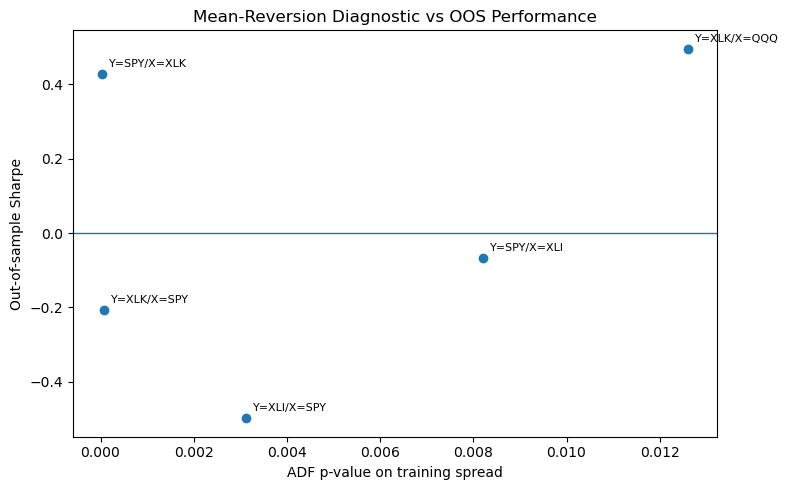

In [50]:
plt.figure(figsize=(8, 5))
plt.scatter(
    diagnostics_vs_oos["adf_p_value"],
    diagnostics_vs_oos["oos_sharpe"],
)

for _, row in diagnostics_vs_oos.iterrows():
    plt.annotate(
        row["pair"],
        (row["adf_p_value"], row["oos_sharpe"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.axhline(0, linewidth=1)
plt.xlabel("ADF p-value on training spread")
plt.ylabel("Out-of-sample Sharpe")
plt.title("Mean-Reversion Diagnostic vs OOS Performance")
plt.tight_layout()
plt.show()

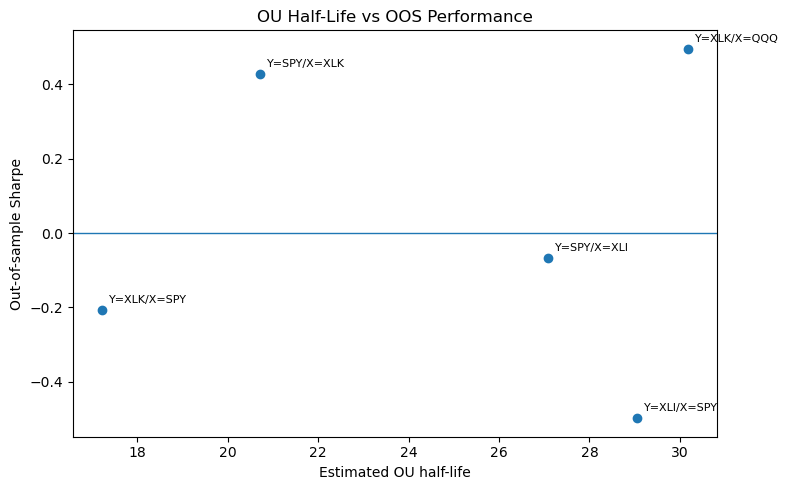

In [52]:
plt.figure(figsize=(8, 5))
plt.scatter(
    diagnostics_vs_oos["ou_half_life"],
    diagnostics_vs_oos["oos_sharpe"],
)

for _, row in diagnostics_vs_oos.iterrows():
    plt.annotate(
        row["pair"],
        (row["ou_half_life"], row["oos_sharpe"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.axhline(0, linewidth=1)
plt.xlabel("Estimated OU half-life")
plt.ylabel("Out-of-sample Sharpe")
plt.title("OU Half-Life vs OOS Performance")
plt.tight_layout()
plt.show()